In [24]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import os

In [25]:
RESULTS_PATH = "res.csv"

In [26]:
# Load the results
results = pandas.read_csv(RESULTS_PATH)
results

,Filename,Method,Timesteps,Density,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),Avg. err,AITS
0,density100_dpm3_nfe50.log,DPM3,50,100,0.8184,0.3944,10.1289,0.2129,0.0752,0.1769,0.496
1,density5_dpm3_nfe50.log,DPM3,50,5,0.8154,0.4424,10.1407,0.2773,0.1387,0.2428,0.300
2,density25_ddim500.log,DDIM,500,25,0.8184,0.2998,9.7716,0.0703,0.0139,0.0572,3.897
3,density2_ddim500.log,DDIM,500,2,0.7959,0.4358,9.9108,0.3164,0.2305,0.3862,2.011
4,density5_ddim500.log,DDIM,500,5,0.8145,0.3687,9.8105,0.0488,0.0139,0.0445,3.907
5,density5_dpm3_nfe100.log,DPM3,100,5,0.8125,0.4190,10.1236,0.2793,0.1375,0.2536,0.599
6,density25_dpm2_nfe100.log,DPM2,100,25,0.8105,0.3713,10.1998,0.2285,0.0811,0.1819,0.605
7,density100_ddim500.log,DDIM,500,100,0.8047,0.3198,9.8128,0.0645,0.0121,0.0577,3.904
8,density1_ddim100.log,DDIM,100,1,0.7930,0.4284,9.6710,0.0000,0.0000,0.0064,1.197
9,density25_dpm3_nfe250.log,DPM3,250,25,0.8125,0.3288,10.1361,0.0703,0.0113,0.0567,1.611


In [27]:
# rows with missing values
missing = results[results.isnull().any(axis=1)]
missing.shape

(0, 11)

In [28]:
# sort by method, timesteps, density
results = results.sort_values(by=["Method", "Timesteps", "Density"])
results

,Filename,Method,Timesteps,Density,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),Avg. err,AITS
22,density100_ddim5.log,DDIM,5,100,0.3740,24.7267,5.6327,0.3672,0.1477,0.2473,0.805
33,density1_ddim20.log,DDIM,20,1,0.5732,6.4740,8.2088,0.0088,0.0088,0.0206,0.655
55,density5_ddim20.log,DDIM,20,5,0.6406,4.7051,8.5126,0.1416,0.0490,0.0976,0.518
43,density25_ddim20.log,DDIM,20,25,0.6836,3.2819,8.6388,0.1895,0.0491,0.1133,0.515
18,density100_ddim20.log,DDIM,20,100,0.7139,2.5676,8.6642,0.1621,0.0426,0.1113,0.514
32,density1_ddim50.log,DDIM,50,1,0.7520,0.9757,9.4217,0.0010,0.0010,0.0084,0.716
54,density5_ddim50.log,DDIM,50,5,0.7900,0.6351,9.3697,0.0635,0.0205,0.0548,0.717
20,density25_ddim50.log,DDIM,50,25,0.8076,0.3537,9.5586,0.1006,0.0200,0.0675,0.715
51,density100_ddim50.log,DDIM,50,100,0.7939,0.3665,9.6019,0.0967,0.0176,0.0676,0.716
8,density1_ddim100.log,DDIM,100,1,0.7930,0.4284,9.6710,0.0000,0.0000,0.0064,1.197


In [29]:
# get timesteps=500
timesteps_500 = results[results["Timesteps"] == 500]
timesteps_500

,Filename,Method,Timesteps,Density,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),Avg. err,AITS
11,density1_ddim500.log,DDIM,500,1,0.8018,0.3956,9.8267,0.0010,0.0010,0.0069,3.903
3,density2_ddim500.log,DDIM,500,2,0.7959,0.4358,9.9108,0.3164,0.2305,0.3862,2.011
4,density5_ddim500.log,DDIM,500,5,0.8145,0.3687,9.8105,0.0488,0.0139,0.0445,3.907
2,density25_ddim500.log,DDIM,500,25,0.8184,0.2998,9.7716,0.0703,0.0139,0.0572,3.897
7,density100_ddim500.log,DDIM,500,100,0.8047,0.3198,9.8128,0.0645,0.0121,0.0577,3.904
53,density1_dpm2_nfe500.log,DPM2,500,1,0.7822,0.3370,10.0546,0.0029,0.0029,0.0107,3.191
25,density5_dpm2_nfe500.log,DPM2,500,5,0.8047,0.3778,10.0318,0.0605,0.0186,0.0503,3.194
58,density25_dpm2_nfe500.log,DPM2,500,25,0.8105,0.3254,10.1132,0.0664,0.0120,0.0559,3.193
28,density100_dpm2_nfe500.log,DPM2,500,100,0.8125,0.3268,10.0249,0.0713,0.0120,0.0580,3.194
27,density1_dpm3_nfe500.log,DPM3,500,1,0.7842,0.3368,10.0578,0.0029,0.0029,0.0109,4.003


In [30]:
# value counts for density
density_counts = timesteps_500["Density"].value_counts()
density_counts

Density
1      3
5      3
25     3
100    3
2      1
Name: count, dtype: int64

In [31]:
# remove density=2
timesteps_500 = timesteps_500[timesteps_500["Density"] != 2]
timesteps_500

,Filename,Method,Timesteps,Density,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),Avg. err,AITS
11,density1_ddim500.log,DDIM,500,1,0.8018,0.3956,9.8267,0.0010,0.0010,0.0069,3.903
4,density5_ddim500.log,DDIM,500,5,0.8145,0.3687,9.8105,0.0488,0.0139,0.0445,3.907
2,density25_ddim500.log,DDIM,500,25,0.8184,0.2998,9.7716,0.0703,0.0139,0.0572,3.897
7,density100_ddim500.log,DDIM,500,100,0.8047,0.3198,9.8128,0.0645,0.0121,0.0577,3.904
53,density1_dpm2_nfe500.log,DPM2,500,1,0.7822,0.3370,10.0546,0.0029,0.0029,0.0107,3.191
25,density5_dpm2_nfe500.log,DPM2,500,5,0.8047,0.3778,10.0318,0.0605,0.0186,0.0503,3.194
58,density25_dpm2_nfe500.log,DPM2,500,25,0.8105,0.3254,10.1132,0.0664,0.0120,0.0559,3.193
28,density100_dpm2_nfe500.log,DPM2,500,100,0.8125,0.3268,10.0249,0.0713,0.0120,0.0580,3.194
27,density1_dpm3_nfe500.log,DPM3,500,1,0.7842,0.3368,10.0578,0.0029,0.0029,0.0109,4.003
16,density5_dpm3_nfe500.log,DPM3,500,5,0.8037,0.3776,10.0320,0.0596,0.0186,0.0502,5.559


In [32]:
# change density 25 to 49, density 100 to 196
timesteps_500["Density"] = timesteps_500["Density"].replace({25: 49, 100: 196})
timesteps_500

/tmp/ipykernel_2654/1015773887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timesteps_500["Density"] = timesteps_500["Density"].replace({25: 49, 100: 196})


,Filename,Method,Timesteps,Density,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),Avg. err,AITS
11,density1_ddim500.log,DDIM,500,1,0.8018,0.3956,9.8267,0.0010,0.0010,0.0069,3.903
4,density5_ddim500.log,DDIM,500,5,0.8145,0.3687,9.8105,0.0488,0.0139,0.0445,3.907
2,density25_ddim500.log,DDIM,500,49,0.8184,0.2998,9.7716,0.0703,0.0139,0.0572,3.897
7,density100_ddim500.log,DDIM,500,196,0.8047,0.3198,9.8128,0.0645,0.0121,0.0577,3.904
53,density1_dpm2_nfe500.log,DPM2,500,1,0.7822,0.3370,10.0546,0.0029,0.0029,0.0107,3.191
25,density5_dpm2_nfe500.log,DPM2,500,5,0.8047,0.3778,10.0318,0.0605,0.0186,0.0503,3.194
58,density25_dpm2_nfe500.log,DPM2,500,49,0.8105,0.3254,10.1132,0.0664,0.0120,0.0559,3.193
28,density100_dpm2_nfe500.log,DPM2,500,196,0.8125,0.3268,10.0249,0.0713,0.0120,0.0580,3.194
27,density1_dpm3_nfe500.log,DPM3,500,1,0.7842,0.3368,10.0578,0.0029,0.0029,0.0109,4.003
16,density5_dpm3_nfe500.log,DPM3,500,5,0.8037,0.3776,10.0320,0.0596,0.0186,0.0502,5.559


In [33]:
def plot_line_chart(df, x_col, y_col, z):
    """
    Plot a line chart for the given dataframe.
    :param df: DataFrame to plot
    :param x_col: Column name for x-axis
    :param y_col: Column name for y-axis
    :param z: Column name for z-axis
    """
    plt.figure(figsize=(10, 6))
    # sort by z, then by x
    df = df.sort_values(by=[z, x_col])
    # different markers for each group, dotted lines
    markers = ["o", "s", "D", "^", "v", "<", ">", "p", "*"]
    for i, (label, df_group) in enumerate(df.groupby(z)):
        plt.plot(
            df_group[x_col],
            df_group[y_col],
            marker=markers[i % len(markers)],
            label=label,
            linestyle="--",
        )
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col} by {z}")
    plt.legend()
    plt.grid()
    plt.show()

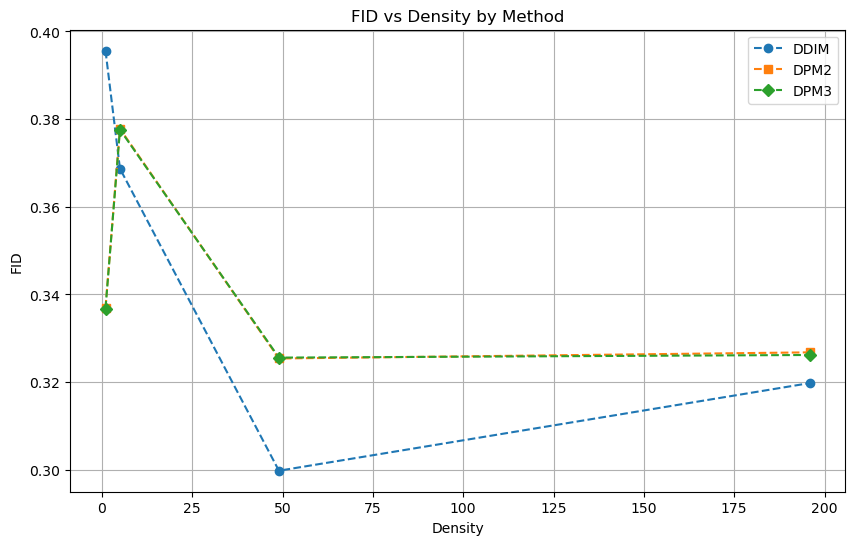

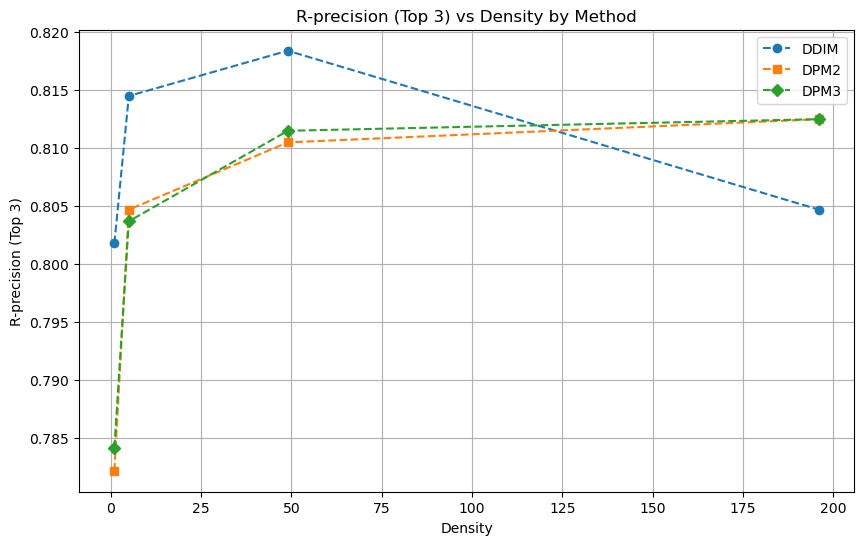

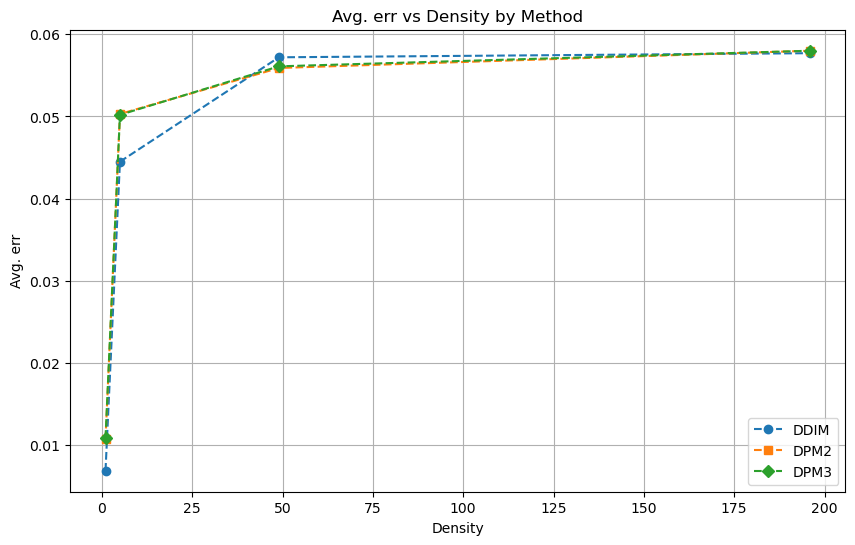

In [34]:
plot_line_chart(timesteps_500, "Density", "FID", "Method")
plot_line_chart(timesteps_500, "Density", "R-precision (Top 3)", "Method")
plot_line_chart(timesteps_500, "Density", "Avg. err", "Method")
# plot_line_chart(timesteps_500, "Density", "Loc. err (50 cm)", "Method")

In [35]:
# for each column in timesteps and density, show value counts
def value_counts_by_density_and_timesteps(df):
    """
    Show value counts for each column in the dataframe by density and timesteps.
    :param df: DataFrame to process
    """
    for col in df.columns:
        if col in ["Density", "Timesteps"]:
            print(f"Value counts for {col}:")
            print(df.groupby(["Density", "Timesteps"])[col].value_counts())
            print()

In [36]:
# get timesteps=500 or 1000
timesteps_500_1000 = results[results["Timesteps"].isin([500, 1000])]
timesteps_500_1000 = timesteps_500_1000[timesteps_500_1000["Density"] != 2]
timesteps_500_1000

,Filename,Method,Timesteps,Density,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),Avg. err,AITS
11,density1_ddim500.log,DDIM,500,1,0.8018,0.3956,9.8267,0.0010,0.0010,0.0069,3.903
4,density5_ddim500.log,DDIM,500,5,0.8145,0.3687,9.8105,0.0488,0.0139,0.0445,3.907
2,density25_ddim500.log,DDIM,500,25,0.8184,0.2998,9.7716,0.0703,0.0139,0.0572,3.897
7,density100_ddim500.log,DDIM,500,100,0.8047,0.3198,9.8128,0.0645,0.0121,0.0577,3.904
44,density1.log,DDPM,1000,1,0.7842,0.4626,9.7586,0.0020,0.0020,0.0089,5.714
14,density5.log,DDPM,1000,5,0.8145,0.3283,9.7683,0.0586,0.0154,0.0417,5.728
41,density25.log,DDPM,1000,25,0.8125,0.3006,9.8046,0.0703,0.0130,0.0575,5.715
47,density100.log,DDPM,1000,100,0.8145,0.3044,9.7277,0.0596,0.0099,0.0572,5.695
53,density1_dpm2_nfe500.log,DPM2,500,1,0.7822,0.3370,10.0546,0.0029,0.0029,0.0107,3.191
25,density5_dpm2_nfe500.log,DPM2,500,5,0.8047,0.3778,10.0318,0.0605,0.0186,0.0503,3.194


In [37]:
value_counts_by_density_and_timesteps(timesteps_500_1000)

Value counts for Timesteps:
Density  Timesteps
1        500          3
         1000         1
5        500          3
         1000         1
25       500          3
         1000         1
100      500          3
         1000         1
Name: count, dtype: int64

Value counts for Density:
Density  Timesteps
1        500          3
         1000         1
5        500          3
         1000         1
25       500          3
         1000         1
100      500          3
         1000         1
Name: count, dtype: int64



In [38]:
# change density 25 to 49, density 100 to 196
timesteps_500_1000["Density"] = timesteps_500_1000["Density"].replace(
    {25: 49, 100: 196}
)
timesteps_500_1000

,Filename,Method,Timesteps,Density,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),Avg. err,AITS
11,density1_ddim500.log,DDIM,500,1,0.8018,0.3956,9.8267,0.0010,0.0010,0.0069,3.903
4,density5_ddim500.log,DDIM,500,5,0.8145,0.3687,9.8105,0.0488,0.0139,0.0445,3.907
2,density25_ddim500.log,DDIM,500,49,0.8184,0.2998,9.7716,0.0703,0.0139,0.0572,3.897
7,density100_ddim500.log,DDIM,500,196,0.8047,0.3198,9.8128,0.0645,0.0121,0.0577,3.904
44,density1.log,DDPM,1000,1,0.7842,0.4626,9.7586,0.0020,0.0020,0.0089,5.714
14,density5.log,DDPM,1000,5,0.8145,0.3283,9.7683,0.0586,0.0154,0.0417,5.728
41,density25.log,DDPM,1000,49,0.8125,0.3006,9.8046,0.0703,0.0130,0.0575,5.715
47,density100.log,DDPM,1000,196,0.8145,0.3044,9.7277,0.0596,0.0099,0.0572,5.695
53,density1_dpm2_nfe500.log,DPM2,500,1,0.7822,0.3370,10.0546,0.0029,0.0029,0.0107,3.191
25,density5_dpm2_nfe500.log,DPM2,500,5,0.8047,0.3778,10.0318,0.0605,0.0186,0.0503,3.194


In [39]:
# groupby method, mean AITS and FID over density
def groupby_method_mean(df, groupby_col, mean_cols):
    """
    Group by method and calculate mean for specified columns.
    :param df: DataFrame to process
    :param groupby_col: Column to group by
    :param mean_cols: List of columns to calculate mean for
    """
    grouped = df.groupby(groupby_col)[mean_cols].mean()
    grouped = grouped.reset_index()
    return grouped

In [40]:
grouped = groupby_method_mean(timesteps_500_1000, "Method", ["AITS", "FID"])
grouped

,Method,AITS,FID
0,DDIM,3.90275,0.345975
1,DDPM,5.71300,0.348975
2,DPM2,3.19300,0.341750
3,DPM3,4.36275,0.341550


In [41]:
# remove DPM3
grouped = grouped[grouped["Method"] != "DPM3"]
grouped

,Method,AITS,FID
0,DDIM,3.90275,0.345975
1,DDPM,5.71300,0.348975
2,DPM2,3.19300,0.341750


In [42]:
# if method = DPM2, replace it with DPM3
grouped["Method"] = grouped["Method"].replace("DPM2", "DPM3")
grouped

/tmp/ipykernel_2654/3693524564.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped["Method"] = grouped["Method"].replace("DPM2", "DPM3")


,Method,AITS,FID
0,DDIM,3.90275,0.345975
1,DDPM,5.71300,0.348975
2,DPM3,3.19300,0.341750


In [43]:
# plot FID vs AITS for each method
def plot_fid_vs_aits(df):
    """
    Plot FID vs AITS for each method.
    :param df: DataFrame to plot
    """
    plt.figure(figsize=(4, 3))
    # different markers for each group
    markers = ["o", "s", "D", "^", "v", "<", ">", "p", "*"]
    for i, (label, df_group) in enumerate(df.groupby("Method")):
        plt.plot(
            df_group["AITS"],
            df_group["FID"],
            marker=markers[i % len(markers)],
            label=label,
            linestyle="--",
            markersize=10,
        )
        # add text label for each point
        for j, row in df_group.iterrows():
            plt.text(
                row["AITS"],
                row["FID"],
                f"{row['AITS']:.3f}, {row['FID']:.3f}",
                fontsize=8,
                ha="left",
                va="top",
            )

    # reduce opacity of the grid lines
    plt.gca().xaxis.grid(True, alpha=0.7)
    plt.gca().yaxis.grid(True, alpha=0.7)

    plt.xlabel("AITS")
    plt.ylabel("FID")
    plt.title("FID vs AITS by Method")
    plt.legend()
    plt.grid()
    plt.show()

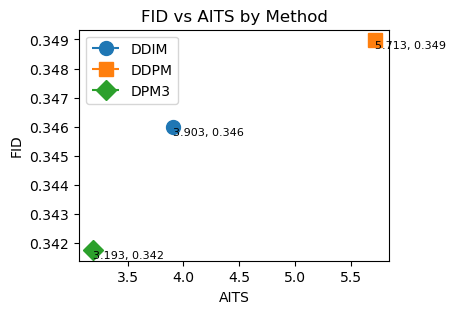

In [44]:
plot_fid_vs_aits(grouped)

In [600]:
# extract only DDIM and DPM3
results_dpm = results[
    results["Method"].isin(["DDIM", "DPM3"])
    & (results["Density"] != 2)
    & (~results["Timesteps"].isin([5, 20, 75]))
]
results_dpm

,Filename,Method,Timesteps,Density,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),Avg. err,AITS
32,density1_ddim50.log,DDIM,50,1,0.7520,0.9757,9.4217,0.0010,0.0010,0.0084,0.716
54,density5_ddim50.log,DDIM,50,5,0.7900,0.6351,9.3697,0.0635,0.0205,0.0548,0.717
20,density25_ddim50.log,DDIM,50,25,0.8076,0.3537,9.5586,0.1006,0.0200,0.0675,0.715
51,density100_ddim50.log,DDIM,50,100,0.7939,0.3665,9.6019,0.0967,0.0176,0.0676,0.716
8,density1_ddim100.log,DDIM,100,1,0.7930,0.4284,9.6710,0.0000,0.0000,0.0064,1.197
48,density5_ddim100.log,DDIM,100,5,0.8154,0.3219,9.7238,0.0498,0.0158,0.0455,1.199
45,density25_ddim100.log,DDIM,100,25,0.8232,0.2876,9.7454,0.0791,0.0125,0.0560,1.199
56,density100_ddim100.log,DDIM,100,100,0.8096,0.2985,9.7422,0.0596,0.0115,0.0591,1.198
37,density1_ddim250.log,DDIM,250,1,0.7998,0.3960,9.8295,0.0000,0.0000,0.0063,2.235
50,density5_ddim250.log,DDIM,250,5,0.8125,0.3499,9.8220,0.0479,0.0139,0.0443,2.230


In [601]:
value_counts_by_density_and_timesteps(results_dpm)

Value counts for Timesteps:
Density  Timesteps
1        50           2
         100          2
         250          2
         500          2
5        50           2
         100          2
         250          2
         500          2
25       50           2
         100          2
         250          2
         500          2
100      50           2
         100          2
         250          2
         500          2
Name: count, dtype: int64

Value counts for Density:
Density  Timesteps
1        50           2
         100          2
         250          2
         500          2
5        50           2
         100          2
         250          2
         500          2
25       50           2
         100          2
         250          2
         500          2
100      50           2
         100          2
         250          2
         500          2
Name: count, dtype: int64



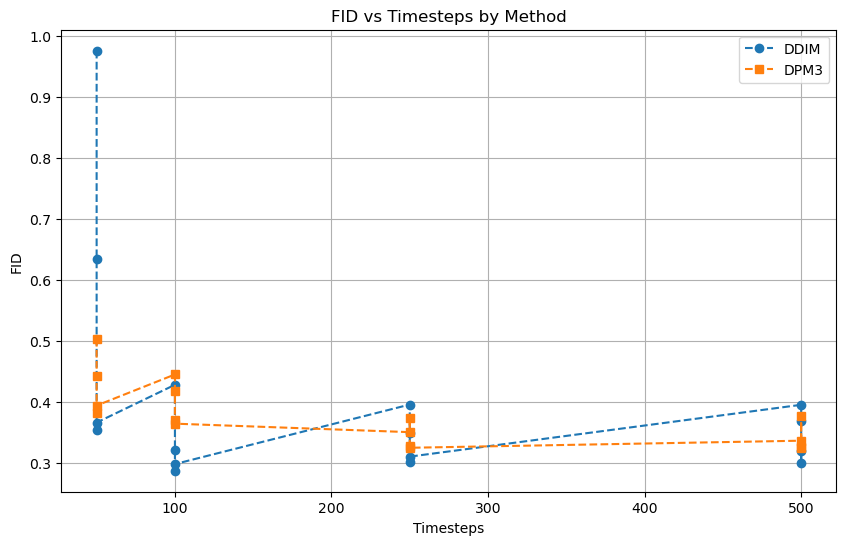

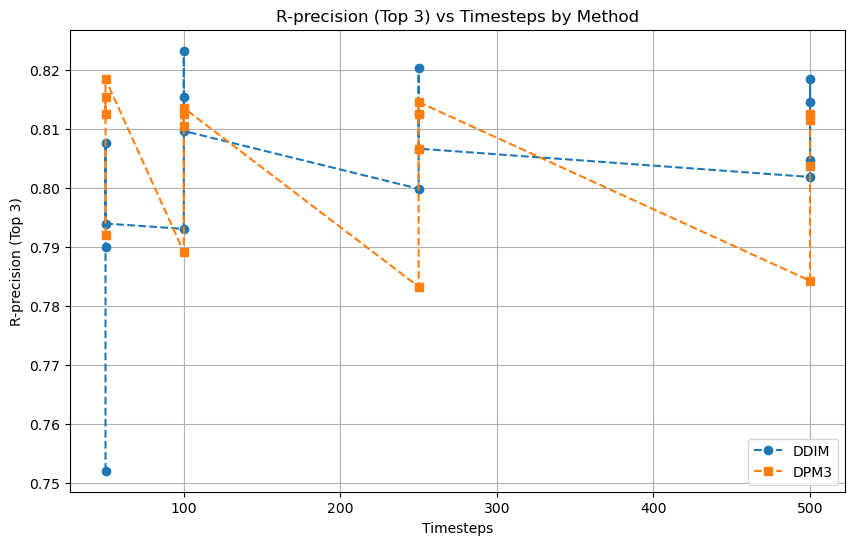

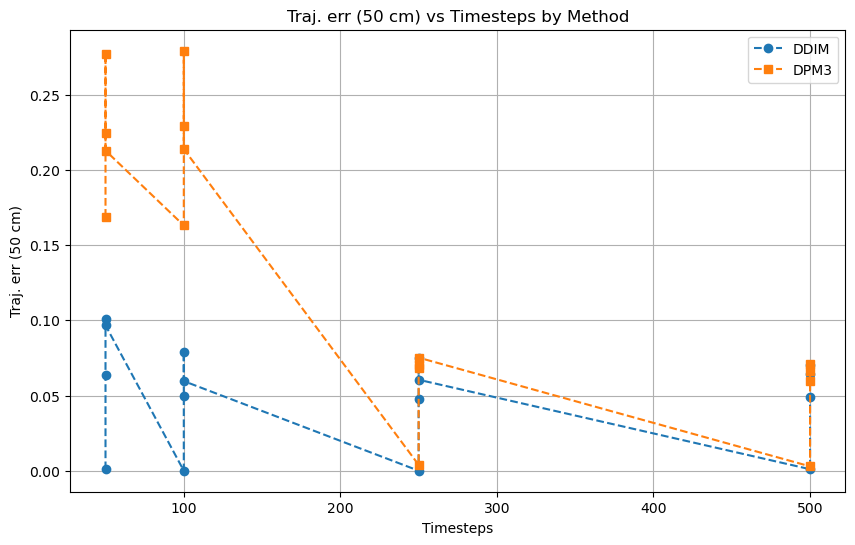

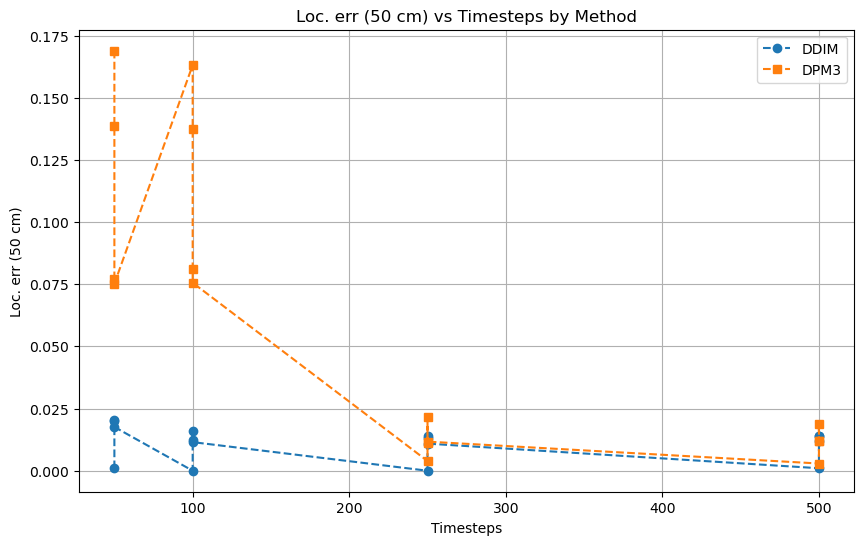

In [603]:
plot_line_chart(results_dpm, "Timesteps", "FID", "Method")  # FID vs Timesteps by Method
plot_line_chart(
    results_dpm, "Timesteps", "R-precision (Top 3)", "Method"
)  # Avg. err vs Timesteps by Method
plot_line_chart(
    results_dpm, "Timesteps", "Traj. err (50 cm)", "Method"
)  # Traj. err vs Timesteps by Method
plot_line_chart(
    results_dpm, "Timesteps", "Loc. err (50 cm)", "Method"
)  # Loc. err vs Timesteps by Method

In [186]:
value_counts_by_density_and_timesteps(results)

Value counts for Timesteps:
Density  Timesteps
1        0            1
         20           1
         50           2
         75           2
         100          2
         250          2
         500          3
         1000         1
2        500          1
5        0            1
         20           1
         50           2
         75           1
         100          2
         250          2
         500          3
         1000         1
25       0            1
         20           2
         50           3
         75           2
         100          3
         250          3
         500          3
         1000         1
100      0            1
         5            1
         20           1
         50           2
         75           1
         100          2
         250          2
         500          3
         1000         1
Name: count, dtype: int64

Value counts for Density:
Density  Timesteps
1        0            1
         20           1
         50      

In [52]:
# extract Density=100
density_100 = results[results["Density"] == 100]
density_100 = density_100.drop(columns=["Density"])

In [53]:
density_100.head()

,Filename,Method,Timesteps,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),AITS
0,density100_dpm3_nfe50.log,DPM3,50,0.8184,0.3944,10.1289,0.2129,0.0752,0.496
7,density100_ddim500.log,DDIM,500,0.8047,0.3198,9.8128,0.0645,0.0121,3.904
15,density100_dpm2_nfe75.log,DPM2,75,0.8174,0.3746,10.1080,0.2129,0.0752,0.449
17,density100_dpm3_nfe100.log,DPM3,100,0.8135,0.3647,10.1023,0.2139,0.0756,1.039
18,density100_ddim20.log,DDIM,20,0.7139,2.5676,8.6642,0.1621,0.0426,0.514


In [54]:
# group by Method, then sort by Timesteps
sorted_df = density_100.sort_values(["Method", "Timesteps"]).reset_index(drop=True)

In [55]:
sorted_df

,Filename,Method,Timesteps,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),AITS
0,density100_ddim5.log,DDIM,5,0.3740,24.7267,5.6327,0.3672,0.1477,0.805
1,density100_ddim20.log,DDIM,20,0.7139,2.5676,8.6642,0.1621,0.0426,0.514
2,density100_ddim50.log,DDIM,50,0.7939,0.3665,9.6019,0.0967,0.0176,0.716
3,density100_ddim100.log,DDIM,100,0.8096,0.2985,9.7422,0.0596,0.0115,1.198
4,density100_ddim250.log,DDIM,250,0.8066,0.3107,9.7867,0.0605,0.0109,2.232
5,density100_ddim500.log,DDIM,500,0.8047,0.3198,9.8128,0.0645,0.0121,3.904
6,density100_1000.log,DDPM,0,0.8057,0.3382,9.7950,0.0586,0.0134,6.727
7,density100.log,DDPM,1000,0.8145,0.3044,9.7277,0.0596,0.0099,5.695
8,density100_dpm2_nfe75.log,DPM2,75,0.8174,0.3746,10.1080,0.2129,0.0752,0.449
9,density100_dpm2_nfe500.log,DPM2,500,0.8125,0.3268,10.0249,0.0713,0.0120,3.194


In [56]:
# unique timesteps and their count
timesteps_count = sorted_df["Timesteps"].value_counts()
print(timesteps_count)

Timesteps
500     3
50      2
100     2
250     2
5       1
20      1
0       1
1000    1
75      1
Name: count, dtype: int64


In [57]:
# extract Timesteps in [50, 100, 250, 500]
timesteps = [50, 100, 250, 500, 1000]
timesteps_df = sorted_df[sorted_df["Timesteps"].isin(timesteps)]

In [58]:
timesteps_df

,Filename,Method,Timesteps,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),AITS
2,density100_ddim50.log,DDIM,50,0.7939,0.3665,9.6019,0.0967,0.0176,0.716
3,density100_ddim100.log,DDIM,100,0.8096,0.2985,9.7422,0.0596,0.0115,1.198
4,density100_ddim250.log,DDIM,250,0.8066,0.3107,9.7867,0.0605,0.0109,2.232
5,density100_ddim500.log,DDIM,500,0.8047,0.3198,9.8128,0.0645,0.0121,3.904
7,density100.log,DDPM,1000,0.8145,0.3044,9.7277,0.0596,0.0099,5.695
9,density100_dpm2_nfe500.log,DPM2,500,0.8125,0.3268,10.0249,0.0713,0.0120,3.194
10,density100_dpm3_nfe50.log,DPM3,50,0.8184,0.3944,10.1289,0.2129,0.0752,0.496
11,density100_dpm3_nfe100.log,DPM3,100,0.8135,0.3647,10.1023,0.2139,0.0756,1.039
12,density100_dpm3_nfe250.log,DPM3,250,0.8145,0.3252,10.0418,0.0752,0.0117,3.014
13,density100_dpm3_nfe500.log,DPM3,500,0.8125,0.3262,10.0247,0.0713,0.0120,4.672


In [59]:
# drop Method=DPM2
timesteps_df = timesteps_df[timesteps_df["Method"] != "DPM2"]
timesteps_df

,Filename,Method,Timesteps,R-precision (Top 3),FID,Diversity,Traj. err (50 cm),Loc. err (50 cm),AITS
2,density100_ddim50.log,DDIM,50,0.7939,0.3665,9.6019,0.0967,0.0176,0.716
3,density100_ddim100.log,DDIM,100,0.8096,0.2985,9.7422,0.0596,0.0115,1.198
4,density100_ddim250.log,DDIM,250,0.8066,0.3107,9.7867,0.0605,0.0109,2.232
5,density100_ddim500.log,DDIM,500,0.8047,0.3198,9.8128,0.0645,0.0121,3.904
7,density100.log,DDPM,1000,0.8145,0.3044,9.7277,0.0596,0.0099,5.695
10,density100_dpm3_nfe50.log,DPM3,50,0.8184,0.3944,10.1289,0.2129,0.0752,0.496
11,density100_dpm3_nfe100.log,DPM3,100,0.8135,0.3647,10.1023,0.2139,0.0756,1.039
12,density100_dpm3_nfe250.log,DPM3,250,0.8145,0.3252,10.0418,0.0752,0.0117,3.014
13,density100_dpm3_nfe500.log,DPM3,500,0.8125,0.3262,10.0247,0.0713,0.0120,4.672
